In [1]:
import Pkg

Pkg.activate(".")
Pkg.instantiate()
import Pkg; Pkg.add("KernelAbstractions")

  Activating new project at `c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.9`
     Project No packages added to or removed from `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.9\Project.toml`
    Manifest No packages added to or removed from `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.9\Manifest.toml`
   Resolving package versions...
    Updating `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.9\Project.toml`
  [63c18a36] + KernelAbstractions v0.9.42
    Updating `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\4\4.9\Manifest.toml`
  [79e6a3ab] + Adapt v4.7.0
  [a9b6321e] + Atomix v1.1.3
  [63c18a36] + KernelAbstractions v0.9.42
  [1914d

In [2]:
using NumericalEarth
using Oceananigans
using Oceananigans.Units
using Oceananigans.Grids: node
using Oceananigans.TurbulenceClosures: VerticalScalarDiffusivity, VerticallyImplicitTimeDiscretization
using Oceananigans.Architectures: architecture
using Oceananigans.Grids: inactive_node
using Oceananigans.Operators: Azá¶œá¶œáµƒ
using Oceananigans.Utils: launch!
using KernelAbstractions: @kernel, @index
using Dates
using Printf
using Statistics
using CUDA

In [3]:
# determining run version/params - :dye_test or :spinup
run_mode = :dye_test

use_rivers = true
resolution_tag = "trial4_9_depth_aware_kz0p5_mindepth30_0p1deg"

# trial 4.9: move freshwater toward nearby columns where mixing can act.

if run_mode == :dye_test
    run_days = 12
elseif run_mode == :spinup
    run_days = 360
else
    error("need right mode")
end

if use_rivers
    run_name = "rivers_on"
else
    run_name = "rivers_off"
end

if run_mode == :dye_test
    output_tag = "$(run_name)_dye_test_$(resolution_tag)"
else
    output_tag = "$(run_name)_spinup"
end

surface_filename = "amazon_$(output_tag)_surface_fields"
free_surface_filename = "amazon_$(output_tag)_free_surface"
dye_3d_filename = "amazon_$(output_tag)_dye_3d"
salinity_3d_filename = "amazon_$(output_tag)_salinity_3d"

checkpoint_filename = "amazon_$(run_name)_spinup_checkpoint.jld2"

"amazon_rivers_on_spinup_checkpoint.jld2"

In [4]:

arch = GPU()

# grid definitions -- amazon river mouth / plume region
long_west = -58.5
long_east = -41.5
lat_south = -7.8
lat_north = 9.2

# trial 4.9 retains the baseline 0.1-degree horizontal resolution.
# keep the 30 m minimum depth so river mixing has an active cell below.
Nx = 170
Ny = 170
Nz = 20

long_river = -49.5
lat_river  = 0.16

depth = 4000meters # decreased depth to 4k for this test 

z = ExponentialDiscretization(Nz, -depth, 0; scale = depth/4, mutable = false)
underlying_grid = LatitudeLongitudeGrid(
    arch;
    size = (Nx, Ny, Nz),
    halo = (5, 5, 4),
    longitude = (long_west, long_east),
    latitude = (lat_south, lat_north),
    z,
    topology = (Bounded, Bounded, Bounded)
)

# use at least 30 m so river-mouth columns can mix below the surface cell
bottom_height = regrid_bathymetry(underlying_grid;
                                  minimum_depth = 30,
                                  interpolation_passes = 10, 
                                  major_basins = 1) # only one major basin here -- atlantic 

grid = ImmersedBoundaryGrid(underlying_grid, GridFittedBottom(bottom_height);
                            active_cells_map=true)


                        

[ Info: Loading cached bathymetry from C:\Users\meghn\.julia\scratchspaces\904d977b-046a-4731-8b86-9235c0d1ef02\bathymetry_cache\bathymetry_170x170_-58.5_-41.5_-7.799999999999999_9.2_f6c0b31a.jld2


170Ã—170Ã—20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5Ã—5Ã—4 halo:
â”œâ”€â”€ immersed_boundary: GridFittedBottom(mean(z)=-1078.27, min(z)=-4000.0, max(z)=0.0)
â”œâ”€â”€ underlying_grid: 170Ã—170Ã—20 LatitudeLongitudeGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5Ã—5Ã—4 halo
â”œâ”€â”€ longitude: Bounded  Î» âˆˆ [-58.5, -41.5] regularly spaced with Î”Î»=0.1
â”œâ”€â”€ latitude:  Bounded  Ï† âˆˆ [-7.8, 9.2]    regularly spaced with Î”Ï†=0.1
â””â”€â”€ z:         Bounded  z âˆˆ [-4000.0, 0.0] variably spaced with min(Î”z)=16.5232, max(Î”z)=738.605

In [5]:

# trial 4.9 focuses on the river-salinity test, so redi is left out.
vertical_mixing = NumericalEarth.Oceans.default_ocean_closure()

# add extra vertical tracer mixing near the river mouth and above 30 meters
const river_mixing_longitude = -49.35
const river_mixing_latitude = -0.15
const river_mixing_kz = 0.5
const river_mixing_depth = 30meters
const river_mixing_half_width = 0.75

@inline function river_mouth_kz(longitude, latitude, z, time)
    inside_longitude = abs(longitude - river_mixing_longitude) <= river_mixing_half_width
    inside_latitude = abs(latitude - river_mixing_latitude) <= river_mixing_half_width
    inside_depth = z >= -river_mixing_depth

    if inside_longitude && inside_latitude && inside_depth
        return river_mixing_kz
    else
        return 0.0
    end
end

river_mixing = VerticalScalarDiffusivity(
    VerticallyImplicitTimeDiscretization();
    Îº = (T = river_mouth_kz,
         S = river_mouth_kz,
         dye = river_mouth_kz,
         e = 0.0)
)

closure = (vertical_mixing, river_mixing)

(CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
â”œâ”€â”€ maximum_tracer_diffusivity: Inf
â”œâ”€â”€ maximum_tke_diffusivity: Inf
â”œâ”€â”€ maximum_viscosity: Inf
â”œâ”€â”€ minimum_tke: 1.0e-9
â”œâ”€â”€ negative_tke_time_scale: 60.0
â”œâ”€â”€ minimum_convective_buoyancy_flux: 1.0e-11
â”œâ”€â”€ tke_time_step: Nothing
â”œâ”€â”€ mixing_length: TKEBasedVerticalDiffusivities.CATKEMixingLength
â”‚   â”œâ”€â”€ CË¢:   1.131
â”‚   â”œâ”€â”€ Cáµ‡:   0.01
â”‚   â”œâ”€â”€ CÊ°â±u: 0.242
â”‚   â”œâ”€â”€ CÊ°â±c: 0.098
â”‚   â”œâ”€â”€ CÊ°â±e: 0.548
â”‚   â”œâ”€â”€ CË¡áµ’u: 0.361
â”‚   â”œâ”€â”€ CË¡áµ’c: 0.369
â”‚   â”œâ”€â”€ CË¡áµ’e: 7.863
â”‚   â”œâ”€â”€ Cáµ˜â¿u: 0.37
â”‚   â”œâ”€â”€ Cáµ˜â¿c: 0.572
â”‚   â”œâ”€â”€ Cáµ˜â¿e: 1.447
â”‚   â”œâ”€â”€ Cá¶œu:  3.705
â”‚   â”œâ”€â”€ Cá¶œc:  4.793
â”‚   â”œâ”€â”€ Cá¶œe:  3.642
â”‚   â”œâ”€â”€ Cáµ‰c:  0.112
â”‚   â”œâ”€â”€ Cáµ‰e:  0.0
â”‚   â”œâ”€â”€ CË¢áµ–:  0.505
â”‚   â”œâ”€â”€ CRiáµŸ: 1.02
â”‚   â””â”€â”€ CRiâ°: 0.254
â””â”€â”€ turbule

In [6]:
free_surface = SplitExplicitFreeSurface(grid; substeps = 70)
momentum_advection = WENOVectorInvariant(order = 5)
tracer_advection = WENO(order = 5)

# create zero-gradient (neumann) boundary conditions for dye 
# "flow out" part of the model 
dye_bcs = FieldBoundaryConditions(
    west   = GradientBoundaryCondition(0),
    east   = GradientBoundaryCondition(0),
    south  = GradientBoundaryCondition(0),
    north  = GradientBoundaryCondition(0),
    top    = FluxBoundaryCondition(0),
    bottom = FluxBoundaryCondition(0)
)

# compile tracer boundary conditions for the model
model_bcs = (
    dye = dye_bcs,
)

# updated sponge layer logic!
# summary: inital sponge was too large + errored. kept on throwing invalidireerror. oceanangians converts the sponge relaxation into a continuous form, which isn't compatible with the gpu, hence the error
# made a manual function creating the gaussian mask for the northern bounday, but then applied the relaxation in discrete form 

# store as gpu-accessible constant
const north_sponge_mask = GaussianMask{:y}(
    center = 9.2,
    width = 0.25
)

# store as a gpu-accessible constant
const north_sponge_rate = 1 / 5days

# apply gaussian dye relaxation in discrete form
@inline function north_dye_sponge(i, j, k, grid, clock, model_fields)
    # get the coordinates of dye cell
    x, y, z = node(i, j, k, grid, Center(), Center(), Center())

    # evaluate gaussian mask from oceaningans at this cell
    mask = north_sponge_mask(x, y, z)

    # read the local dye concentration + relax towards 0 
    dye = @inbounds model_fields.dye[i, j, k]
    return -north_sponge_rate * mask * dye

end

# use the discrete form to avoid the bug 
dye_sponge = Forcing(
    north_dye_sponge;
    discrete_form = true
)

# apply the sponge only to dye
model_forcing = (
    dye = dye_sponge,
)
                        
# dd dye with the original numericalearth momentum, tracer, and closure settings.
ocean = ocean_simulation(grid;
                         momentum_advection, tracer_advection, free_surface,
                         closure = closure,
                         tracers = (:T, :S, :dye),
                         boundary_conditions = model_bcs,
                         forcing = model_forcing
                         )

# instead of floating dye patch, new dye patch centered on the river mouth, fading with distance
# dye is initially deposited only in the upper 10 meters
@inline function dye_initial_condition(x, y, z)
    horizontal_width = 0.5

    horizontal_blob = exp(-((x - long_river)^2 + (y - lat_river)^2) / horizontal_width^2)

    if z > -10
        return horizontal_blob
    else
        return 0
    end
end

# print the model structure so we can check that dye is listed as a tracer and that the boundary conditions were set to 0 gradient
@info "We've built an ocean simulation with model:"
@show ocean.model
@show ocean.model.tracers.dye.boundary_conditions



[ Info: We've built an ocean simulation with model:


ocean.model = HydrostaticFreeSurfaceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
â”œâ”€â”€ grid: 170Ã—170Ã—20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5Ã—5Ã—4 halo
â”œâ”€â”€ timestepper: SplitRungeKuttaTimeStepper
â”œâ”€â”€ tracers: (T, S, dye, e)
â”œâ”€â”€ closure: Tuple with 2 closures:
â”‚   â”œâ”€â”€ CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
â”‚   â””â”€â”€ VerticalScalarDiffusivity{VerticallyImplicitTimeDiscretization}(Î½=0.0, Îº=(T=river_mouth_kz (generic function with 1 method), S=river_mouth_kz (generic function with 1 method), dye=river_mouth_kz (generic function with 1 method), e=0.0))
â”œâ”€â”€ buoyancy: SeawaterBuoyancy with g=9.80665 and BoussinesqEquationOfState{Float64} with gÌ‚ = NegativeZDirection()
â”œâ”€â”€ free surface: SplitExplicitFreeSurface with gravitational acceleration 9.80665 m sâ»Â²
â”‚   â””â”€â”€ substepping: FixedSubstepNumber(50)
â”œâ”€â”€ advection scheme: 
â”‚   â”œâ”€â”€ m

Oceananigans.FieldBoundaryConditions, with boundary conditions
â”œâ”€â”€ west: GradientBoundaryCondition: 0.0
â”œâ”€â”€ east: GradientBoundaryCondition: 0.0
â”œâ”€â”€ south: GradientBoundaryCondition: 0.0
â”œâ”€â”€ north: GradientBoundaryCondition: 0.0
â”œâ”€â”€ bottom: FluxBoundaryCondition: 0.0
â”œâ”€â”€ top: FluxBoundaryCondition: 0.0
â””â”€â”€ immersed: FluxBoundaryCondition: Nothing

In [7]:
# ask for ecco credentials at runtime so they are not saved in the notebook
@assert haskey(ENV, "ECCO_USERNAME") "Set ECCO_USERNAME before running this cell"
@assert haskey(ENV, "ECCO_WEBDAV_PASSWORD") "Set ECCO_WEBDAV_PASSWORD before running this cell"


date = DateTime(1993, 1, 1)

ecco_variables = (:temperature, :salinity)
ecco_set = MetadataSet(ecco_variables; dataset = ECCO4Monthly(), date)

# we aren't initializing the tracer just yet (first spinning-up the model for a year)  
# print out all of the tracers 
set!(ocean.model, ecco_set)
@show keys(ocean.model.tracers)

keys(ocean.model.tracers) = (:T, :S, :dye, :e)


(:T, :S, :dye, :e)

In [8]:

land = JRA55PrescribedLand(arch)
atmosphere = JRA55PrescribedAtmosphere(arch)
ocean_surface = SurfaceRadiationProperties(albedo = LatitudeDependentAlbedo())
radiation = JRA55PrescribedRadiation(arch; ocean_surface)

640Ã—320Ã—1Ã—2920 PrescribedRadiation on LatitudeLongitudeGrid:
â”œâ”€â”€ times: 2920-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
â”œâ”€â”€ stefan_boltzmann_constant: 5.67037e-8
â””â”€â”€ surface_properties: (:ocean, :sea_ice)

In [9]:
# trial 4.9 sends river water to nearby columns where vertical mixing can work
const interface_computations = NumericalEarth.EarthSystemModels.InterfaceComputations
const river_spread_radius = Ref(5)

struct RiverSpread{F, A, M, C}
    raw_flux :: F
    surface_area :: A
    mixing_ready :: M
    recipient_count :: C
end

# save surface area and whether the column has a second active layer
@kernel function save_river_cells!(surface_area, mixing_ready, grid)
    i, j = @index(Global, NTuple)
    k = grid.Nz
    surface_active = !inactive_node(i, j, k, grid, Center(), Center(), Center())
    below_active = !inactive_node(i, j, k - 1, grid, Center(), Center(), Center())
    longitude, latitude, z = node(i, j, k, grid, Center(), Center(), Center())
    inside_longitude = abs(longitude - river_mixing_longitude) <= river_mixing_half_width
    inside_latitude = abs(latitude - river_mixing_latitude) <= river_mixing_half_width
    inside_mixing_box = inside_longitude && inside_latitude

    if surface_active
        @inbounds surface_area[i, j, 1] = Azá¶œá¶œáµƒ(i, j, k, grid)
    else
        @inbounds surface_area[i, j, 1] = 0
    end

    if surface_active && below_active && inside_mixing_box
        @inbounds mixing_ready[i, j, 1] = 1
    else
        @inbounds mixing_ready[i, j, 1] = 0
    end
end

# count each source cell's possible destinations once
@kernel function count_river_targets!(recipient_count, surface_area, mixing_ready, Nx, Ny, radius)
    i, j = @index(Global, NTuple)
    source_area = @inbounds surface_area[i, j, 1]

    if source_area > 0
        ready_neighbors = 0
        for neighbor_i in max(1, i - radius):min(Nx, i + radius)
            for neighbor_j in max(1, j - radius):min(Ny, j + radius)
                neighbor_area = @inbounds surface_area[neighbor_i, neighbor_j, 1]
                neighbor_ready = @inbounds mixing_ready[neighbor_i, neighbor_j, 1] > 0
                if neighbor_area > 0 && neighbor_ready
                    ready_neighbors += 1
                end
            end
        end

        @inbounds recipient_count[i, j, 1] = ready_neighbors
    else
        @inbounds recipient_count[i, j, 1] = 0
    end
end

# give each source cell's water to nearby columns where mixing can act
@kernel function spread_river_water!(spread_flux, raw_flux, surface_area, mixing_ready, recipient_count, Nx, Ny, radius)
    i, j = @index(Global, NTuple)
    destination_area = @inbounds surface_area[i, j, 1]
    destination_ready = @inbounds mixing_ready[i, j, 1] > 0
    transported_mass = zero(eltype(spread_flux))

    if destination_area > 0
        for source_i in max(1, i - radius):min(Nx, i + radius)
            for source_j in max(1, j - radius):min(Ny, j + radius)
                source_area = @inbounds surface_area[source_i, source_j, 1]

                if source_area > 0
                    stored_count = @inbounds recipient_count[source_i, source_j, 1]
                    destination_accepts = destination_ready && stored_count > 0
                    number_of_recipients = stored_count

                    # if no deep neighbor exists, leave this source unchanged
                    if stored_count == 0 && i == source_i && j == source_j
                        destination_accepts = true
                        number_of_recipients = 1
                    end

                    if destination_accepts && number_of_recipients > 0
                        source_flux = @inbounds raw_flux[source_i, source_j, 1]
                        transported_mass += source_flux * source_area / number_of_recipients
                    end
                end
            end
        end

        @inbounds spread_flux[i, j, 1] = transported_mass / destination_area
    else
        @inbounds spread_flux[i, j, 1] = zero(eltype(spread_flux))
    end
end

function RiverSpread(grid)
    raw_flux = Field{Center, Center, Nothing}(grid)
    surface_area = Field{Center, Center, Nothing}(grid)
    mixing_ready = Field{Center, Center, Nothing}(grid)
    recipient_count = Field{Center, Center, Nothing}(grid)
    launch!(architecture(grid), grid, :xy, save_river_cells!, surface_area, mixing_ready, grid)
    return RiverSpread(raw_flux, surface_area, mixing_ready, recipient_count)
end

# save the original flux, then replace it with the spread flux
function interface_computations.correct_state!(correction::RiverSpread, exchanger, grid)
    freshwater_flux = exchanger.state.freshwater_flux
    copyto!(parent(correction.raw_flux.data), parent(freshwater_flux.data))
    radius = river_spread_radius[]
    launch!(architecture(grid), grid, :xy, count_river_targets!,
            correction.recipient_count, correction.surface_area, correction.mixing_ready,
            grid.Nx, grid.Ny, radius)
    launch!(architecture(grid), grid, :xy, spread_river_water!,
            freshwater_flux, correction.raw_flux, correction.surface_area, correction.mixing_ready, correction.recipient_count,
            grid.Nx, grid.Ny, radius)
    return nothing
end

# attach this correction when numericalearth makes the land exchange field
function interface_computations.ComponentExchanger(::PrescribedLand, grid)
    state = (; freshwater_flux = Field{Center, Center, Nothing}(grid))
    correction = RiverSpread(grid)
    return interface_computations.ComponentExchanger(state, nothing, correction)
end

In [10]:
# trial 4.9 requires the river freshwater forcing
@assert use_rivers "trial 4.9 requires use_rivers = true"
land_component = land

# build the regional ocean model
coupled_model = EarthSystemModel(
    ;
    ocean,
    atmosphere,
    land = land_component,
    radiation
)

# verify that spreading preserves the active-ocean freshwater transport
land_exchange = coupled_model.interfaces.exchanger.land
river_spreading = land_exchange.correction
raw_flux = Array(interior(river_spreading.raw_flux, :, :, 1))
surface_area = Array(interior(river_spreading.surface_area, :, :, 1))
mixing_ready = Array(interior(river_spreading.mixing_ready, :, :, 1))
longitude_centers = Array(Î»nodes(grid, Center()))
latitude_centers = Array(Ï†nodes(grid, Center()))

# search up to five cells away for a column where mixing can act
raw_positive_flux = max.(raw_flux, 0.0)
selected_radius = 5
river_spread_radius[] = selected_radius
@info "trial 4.9 depth-aware river radius" selected_radius

# restore the raw field and apply spreading once with the selected radius
freshwater_flux_field = land_exchange.state.freshwater_flux
copyto!(parent(freshwater_flux_field.data), parent(river_spreading.raw_flux.data))
interface_computations.correct_state!(river_spreading, land_exchange, grid)
raw_flux = Array(interior(river_spreading.raw_flux, :, :, 1))
spread_flux = Array(interior(freshwater_flux_field, :, :, 1))
raw_transport = sum(raw_flux .* surface_area)
spread_transport = sum(spread_flux .* surface_area)
conservation_error = abs(spread_transport - raw_transport) / max(abs(raw_transport), eps())
@info "trial 4.9 freshwater spreading check" raw_transport spread_transport conservation_error maximum(raw_flux) maximum(spread_flux) selected_radius
@assert conservation_error < 1e-10 "deep-column spreading did not conserve freshwater transport"

# check that the extra mixing turns off below 30 meters
@assert river_mouth_kz(river_mixing_longitude, river_mixing_latitude, -10, 0) == river_mixing_kz
@assert river_mouth_kz(river_mixing_longitude, river_mixing_latitude, -40, 0) == 0.0
@info "trial 4.9 river mixing check" river_mixing_longitude river_mixing_latitude river_mixing_kz river_mixing_depth river_mixing_half_width

# timestep used for both the 12-day test and 360-day spin-up
time_step = 3minutes

simulation = Simulation(
    coupled_model;
    Î”t = time_step,
    stop_time = run_days * days
)

# print advective cfl in log 
advective_cfl = AdvectiveCFL(time_step)


â”Œ Warning: 1440Ã—720Ã—1Ã—365 PrescribedLand tracks time as Float32 but the EarthSystemModel clock uses Float64; coercing the component clock to keep components synchronized.
â”” @ NumericalEarth.EarthSystemModels C:\Users\meghn\.julia\packages\NumericalEarth\eKhWQ\src\EarthSystemModels\components.jl:136
â”Œ Info: trial 4.9 depth-aware river radius
â””   selected_radius = 5
â”Œ Info: trial 4.9 freshwater spreading check
â”‚   raw_transport = 1.1018805993114366e8
â”‚   spread_transport = 1.1018805993114367e8
â”‚   conservation_error = 1.3523390105206833e-16
â”‚   maximum(raw_flux) = 0.12167064845561981
â”‚   maximum(spread_flux) = 0.05256900191307068
â””   selected_radius = 5
â”Œ Info: trial 4.9 river mixing check
â”‚   river_mixing_longitude = -49.35
â”‚   river_mixing_latitude = -0.15
â”‚   river_mixing_kz = 0.5
â”‚   river_mixing_depth = 30.0
â””   river_mixing_half_width = 0.75


CFL{Float64, typeof(Oceananigans.Advection.cell_advection_timescale)}(180.0, Oceananigans.Advection.cell_advection_timescale)

In [11]:
# trial 4.9 checks the new river destinations before the full run
longitude_centers = Array(Î»nodes(grid, Center()))
latitude_centers = Array(Ï†nodes(grid, Center()))

positive_spread_flux = max.(spread_flux, 0.0)
amazon_window = falses(size(spread_flux))
mixing_box = falses(size(spread_flux))

for j in eachindex(latitude_centers)
    for i in eachindex(longitude_centers)
        longitude = longitude_centers[i]
        latitude = latitude_centers[j]

        amazon_window[i, j] = abs(longitude - long_river) <= 2.0 &&
                              abs(latitude - lat_river) <= 2.0

        mixing_box[i, j] = abs(longitude - river_mixing_longitude) <= river_mixing_half_width &&
                           abs(latitude - river_mixing_latitude) <= river_mixing_half_width
    end
end

amazon_forced_cells = findall(amazon_window .& (positive_spread_flux .> 0))
mixing_forced_cells = findall(mixing_box .& (positive_spread_flux .> 0))
@assert !isempty(amazon_forced_cells) "no positive freshwater cells were found near the amazon mouth"

amazon_transport = sum(positive_spread_flux[amazon_window] .* surface_area[amazon_window])
mixing_transport = sum(positive_spread_flux[mixing_box] .* surface_area[mixing_box])
@assert amazon_transport > 0 "freshwater transport near the amazon mouth is zero"
mixing_transport_fraction = mixing_transport / amazon_transport
mixing_ocean_cells = count(mixing_box .& (surface_area .> 0))
ready_river_mask = amazon_window .& (positive_spread_flux .> 0) .& (mixing_ready .> 0)
ready_transport = sum(positive_spread_flux[ready_river_mask] .* surface_area[ready_river_mask])
ready_transport_fraction = ready_transport / amazon_transport
maximum_raw_amazon_flux = maximum(raw_positive_flux[amazon_window])
maximum_spread_amazon_flux = maximum(positive_spread_flux[amazon_window])
maximum_flux_ratio = maximum_spread_amazon_flux / maximum_raw_amazon_flux

forced_longitudes = [longitude_centers[cell[1]] for cell in amazon_forced_cells]
forced_latitudes = [latitude_centers[cell[2]] for cell in amazon_forced_cells]
sorted_forced_cells = sort(amazon_forced_cells; by = cell -> positive_spread_flux[cell], rev = true)
strongest_cell = first(sorted_forced_cells)

amazon_forced_cell_count = length(amazon_forced_cells)
mixing_forced_cell_count = length(mixing_forced_cells)
amazon_longitude_range = (minimum(forced_longitudes), maximum(forced_longitudes))
amazon_latitude_range = (minimum(forced_latitudes), maximum(forced_latitudes))
strongest_longitude = longitude_centers[strongest_cell[1]]
strongest_latitude = latitude_centers[strongest_cell[2]]
strongest_flux = positive_spread_flux[strongest_cell]

@info "trial 4.9 mixing coverage check" amazon_forced_cell_count mixing_ocean_cells mixing_forced_cell_count amazon_longitude_range amazon_latitude_range strongest_longitude strongest_latitude strongest_flux amazon_transport mixing_transport mixing_transport_fraction ready_transport ready_transport_fraction maximum_raw_amazon_flux maximum_spread_amazon_flux maximum_flux_ratio

top_cell_count = min(10, length(sorted_forced_cells))
for rank in 1:top_cell_count
    cell = sorted_forced_cells[rank]
    longitude = longitude_centers[cell[1]]
    latitude = latitude_centers[cell[2]]
    flux = positive_spread_flux[cell]
    inside_mixing_box = mixing_box[cell]
    @info @sprintf("trial 4.9 rank %d: longitude %.3f, latitude %.3f, flux %.6e, inside mixing box %s",
                   rank, longitude, latitude, flux, string(inside_mixing_box))
end

@assert mixing_box[strongest_cell] "the corrected mixing box misses the strongest freshwater cell"
@assert mixing_transport_fraction > 0.5 "the corrected mixing box covers less than half of the nearby freshwater transport"
@assert ready_transport_fraction > 0.5 "less than half of the nearby freshwater transport reaches deep-enough columns"
@assert maximum_flux_ratio <= 1.0 "deep-column spreading increased the maximum amazon freshwater flux"
trial4_9_preflight_passed = true


â”Œ Info: trial 4.9 mixing coverage check
â”‚   amazon_forced_cell_count = 376
â”‚   mixing_ocean_cells = 114
â”‚   mixing_forced_cell_count = 144
â”‚   amazon_longitude_range = (-51.05, -47.55)
â”‚   amazon_latitude_range = (-1.5500000000000005, 2.149999999999999)
â”‚   strongest_longitude = -49.45
â”‚   strongest_latitude = -0.2500000000000006
â”‚   strongest_flux = 0.05256900191307068
â”‚   amazon_transport = 1.0263487506367214e8
â”‚   mixing_transport = 9.834412376985776e7
â”‚   mixing_transport_fraction = 0.9581940223422838
â”‚   ready_transport = 9.834412376985778e7
â”‚   ready_transport_fraction = 0.9581940223422839
â”‚   maximum_raw_amazon_flux = 0.12167064845561981
â”‚   maximum_spread_amazon_flux = 0.05256900191307068
â””   maximum_flux_ratio = 0.432059848289915
[ Info: trial 4.9 rank 1: longitude -49.450, latitude -0.250, flux 5.256900e-02, inside mixing box true
[ Info: trial 4.9 rank 2: longitude -49.550, latitude -0.050, flux 3.154929e-02, inside mixing box true
[ Info: t

true

In [12]:
# confirm that the depth-aware search radius is active
@assert selected_radius == 5 "trial 4.9 expected a radius of five"
@assert river_spread_radius[] == 5 "the depth-aware radius was not applied"
@info "trial 4.9 radius check" selected_radius


â”Œ Info: trial 4.9 radius check
â””   selected_radius = 5


In [13]:
wall_time = Ref(time_ns())

function progress(sim)

    ocean = sim.model.ocean

    u, v, w = ocean.model.velocities

    T = ocean.model.tracers.T
    S = ocean.model.tracers.S
    dye = ocean.model.tracers.dye
    e = ocean.model.tracers.e

    Tmin, Tmax = minimum(T), maximum(T)
    Smin, Smax = minimum(S), maximum(S)
    dyemin, dyemax = minimum(dye), maximum(dye)
    emin, emax = minimum(e), maximum(e)
    cfl = advective_cfl(ocean.model)

    umax = (
        maximum(abs, u),
        maximum(abs, v),
        maximum(abs, w)
    )

    step_time = 1e-9 * (time_ns() - wall_time[])

    msg1 = @sprintf(
        "time: %s, iter: %d",
        prettytime(sim),
        iteration(sim)
    )

    msg2 = @sprintf(
        ", max|u|: (%.3e, %.3e, %.3e) m sâ»Â¹",
        umax[1],
        umax[2],
        umax[3]
    )

    msg3 = @sprintf(
        "\nT:    min = %.6e, max = %.6e Â°C",
        Tmin,
        Tmax
    )

    msg4 = @sprintf(
        "\nS:    min = %.6e, max = %.6e",
        Smin,
        Smax
    )

    msg5 = @sprintf(
        "\ndye:  min = %.6e, max = %.6e",
        dyemin,
        dyemax
    )

    msg6 = @sprintf(
        "\ne:    min = %.6e, max = %.6e mÂ² sâ»Â²",
        emin,
        emax
    )

    msg7 = @sprintf(
        "\nadvective CFL = %.6e",
        cfl
    )

    msg9 = @sprintf(
        "\nwall time since last report: %s\n",
        prettytime(step_time)
    )

    @info msg1 * msg2 * msg3 * msg4 * msg5 * msg6 * msg7 * msg9

    tracer_extrema = (
        Tmin, Tmax,
        Smin, Smax,
        dyemin, dyemax,
        emin, emax
    )

    if dyemin < 0
        warning_message = @sprintf(
            "NEGATIVE DYE DETECTED: min(dye) = %.6e",
            dyemin
        )
        @warn warning_message
    end

    if dyemax > 1
        warning_message = @sprintf(
            "OVERSHOOT DYE DETECTED: max(dye) = %.6e",
            dyemax
        )
        @warn warning_message
    end

    if Smin < 0
        warning_message = @sprintf(
            "NEGATIVE SALINITY DETECTED: min(S) = %.6e",
            Smin
        )
        @warn warning_message
    end

    wall_time[] = time_ns()

    return nothing
end

progress (generic function with 1 method)

In [14]:
# print the progress report every simulated day
add_callback!(simulation, progress, TimeInterval(1days))

In [15]:
# collect surface tracers + velocities
ocean_outputs = merge(
    ocean.model.tracers,
    ocean.model.velocities
)

# collect full 3d salinity
salinity_output = (
    S = ocean.model.tracers.S,
)

# grab the free-surface displacement
free_surface = ocean.model.free_surface.displacement

# save daily surface tracers + velocities in both modes
ocean.output_writers[:surface] = JLD2Writer(
    ocean.model,
    ocean_outputs;
    schedule = TimeInterval(1days),
    filename = surface_filename,
    indices = (:, :, grid.Nz),
    overwrite_existing = true
)

# save daily sea-surface height in both modes
ocean.output_writers[:free_surface] = JLD2Writer(
    ocean.model,
    (; Î· = free_surface);
    schedule = TimeInterval(1days),
    filename = free_surface_filename,
    overwrite_existing = true
)

if run_mode == :dye_test
    dye_output = (
        dye = ocean.model.tracers.dye,
    )

    # save full 3d dye daily for the 5-day test
    ocean.output_writers[:dye_3d] = JLD2Writer(
        ocean.model,
        dye_output;
        schedule = TimeInterval(1days),
        filename = dye_3d_filename,
        overwrite_existing = true
    )

    # save full 3d salinity daily for the short test
    ocean.output_writers[:salinity_3d] = JLD2Writer(
        ocean.model,
        salinity_output;
        schedule = TimeInterval(1days),
        filename = salinity_3d_filename,
        overwrite_existing = true
    )

elseif run_mode == :spinup
    # do not save 3d dye because it remains zero during spin-up

    # save full 3d salinity every 30 days during spin-up
    ocean.output_writers[:salinity_3d] = JLD2Writer(
        ocean.model,
        salinity_output;
        schedule = TimeInterval(30days),
        filename = salinity_3d_filename,
        overwrite_existing = true
    )

    # save a restart checkpoint every 30 days
    simulation.output_writers[:checkpointer] = Checkpointer(
        simulation.model;
        schedule = TimeInterval(30days),
        prefix = "amazon_$(run_name)_spinup_checkpoint",
        cleanup = true,
        overwrite_existing = true
    )
end

JLD2Writer scheduled on TimeInterval(1 day):
â”œâ”€â”€ filepath: amazon_rivers_on_dye_test_trial4_9_depth_aware_kz0p5_mindepth30_0p1deg_salinity_3d.jld2
â”œâ”€â”€ 1 outputs: S
â”œâ”€â”€ array_type: Array{Float32}
â”œâ”€â”€ including: [:coriolis, :buoyancy, :closure]
â”œâ”€â”€ file_splitting: NoFileSplitting
â””â”€â”€ file size: 0 bytes (file not yet created)

In [16]:
# simple check that the added river closure is attached
model_closures = ocean.model.closure
@assert length(model_closures) == 2 "trial 4.9 expected CATKE and river mixing"
@assert model_closures[2] isa VerticalScalarDiffusivity "the river mixing closure is missing from the model"
trial4_9_closure_check_passed = true


true

### trial 4.9 - depth-aware freshwater spreading

this trial searches up to five grid cells from each river source and sends its freshwater to columns where the surface cell and the cell below are both wet. freshwater is divided equally among those eligible columns while conserving total transport.

the river box uses an added vertical diffusivity of 0.5 mÂ²/s through the upper 30 m. if a source has no eligible destination within the search radius, its forcing stays in its original cell so freshwater is not lost.


In [17]:
# stop before the long run if the trial 4.9 setup was not rebuilt and checked
if !(@isdefined trial4_9_preflight_passed)
    error("run the trial 4.9 mixing coverage check before this cell")
end
if !(@isdefined trial4_9_closure_check_passed)
    error("run the trial 4.9 closure check before this cell")
end
@assert trial4_9_preflight_passed "the trial 4.9 preflight did not pass"
@assert trial4_9_closure_check_passed "the trial 4.9 closure check did not pass"
@assert resolution_tag == "trial4_9_depth_aware_kz0p5_mindepth30_0p1deg"
@assert river_mixing_longitude == -49.35
@assert river_mixing_latitude == -0.15
@assert river_mixing_half_width == 0.75
@assert river_mixing_depth == 30meters
@assert river_mixing_kz == 0.5
@assert river_spread_radius[] == selected_radius
@assert iteration(simulation) == 0 "build a new simulation before starting trial 4.9"
@info "trial 4.9 pre-run check passed" selected_radius mixing_transport_fraction ready_transport_fraction river_mixing_longitude river_mixing_latitude river_mixing_half_width river_mixing_depth river_mixing_kz

if run_mode == :dye_test
    # deposit dye immediately for the 12-day test
    set!(ocean.model, dye = dye_initial_condition)

    @show minimum(ocean.model.tracers.dye)
    @show maximum(ocean.model.tracers.dye)

    @info "initial values right after dye is deposited:"
    progress(simulation)

elseif run_mode == :spinup
    # begin the 360-day spin-up with no dye
    set!(ocean.model, dye = 0.0)

    @info "spinup has 0 dye."
    @show minimum(ocean.model.tracers.dye)
    @show maximum(ocean.model.tracers.dye)
end
run!(simulation)

â”Œ Info: trial 4.9 pre-run check passed
â”‚   selected_radius = 5
â”‚   mixing_transport_fraction = 0.9581940223422838
â”‚   ready_transport_fraction = 0.9581940223422839
â”‚   river_mixing_longitude = -49.35
â”‚   river_mixing_latitude = -0.15
â”‚   river_mixing_half_width = 0.75
â”‚   river_mixing_depth = 30.0
â””   river_mixing_kz = 0.5


minimum(ocean.model.tracers.dye) = 0.0


[ Info: initial values right after dye is deposited:


maximum(ocean.model.tracers.dye) = 0.9896538930090968


â”Œ Info: time: 0 seconds, iter: 0, max|u|: (0.000e+00, 0.000e+00, 0.000e+00) m sâ»Â¹
â”‚ T:    min = 2.119264e+00, max = 2.817149e+01 Â°C
â”‚ S:    min = 3.102885e+01, max = 3.669947e+01
â”‚ dye:  min = 0.000000e+00, max = 9.896539e-01
â”‚ e:    min = 0.000000e+00, max = 0.000000e+00 mÂ² sâ»Â²
â”‚ advective CFL = 0.000000e+00
â”” wall time since last report: 1.743 minutes
[ Info: Initializing simulation...
â”Œ Info: time: 0 seconds, iter: 0, max|u|: (0.000e+00, 0.000e+00, 0.000e+00) m sâ»Â¹
â”‚ T:    min = 2.119264e+00, max = 2.817149e+01 Â°C
â”‚ S:    min = 3.102885e+01, max = 3.669947e+01
â”‚ dye:  min = 0.000000e+00, max = 9.896539e-01
â”‚ e:    min = 0.000000e+00, max = 0.000000e+00 mÂ² sâ»Â²
â”‚ advective CFL = 0.000000e+00
â”” wall time since last report: 22.686 seconds
[ Info:     ... simulation initialization complete (4.306 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (4.505 minutes).
â”Œ Info: time: 1 day, iter: 480, max|u|: 

In [18]:

# add the file extension used by fieldtimeseries
surface_filepath = surface_filename * ".jld2"
free_surface_filepath = free_surface_filename * ".jld2"
dye_3d_filepath = dye_3d_filename * ".jld2"
salinity_3d_filepath = salinity_3d_filename * ".jld2"

# load daily surface fields
uo = FieldTimeSeries(surface_filepath, "u"; backend = OnDisk())
vo = FieldTimeSeries(surface_filepath, "v"; backend = OnDisk())
To = FieldTimeSeries(surface_filepath, "T"; backend = OnDisk())
So = FieldTimeSeries(surface_filepath, "S"; backend = OnDisk())
eo = FieldTimeSeries(surface_filepath, "e"; backend = OnDisk())
dye = FieldTimeSeries(surface_filepath, "dye"; backend = OnDisk())
Î·o = FieldTimeSeries(free_surface_filepath, "Î·"; backend = OnDisk())

# load full 3d dye saved daily
dye_3d = FieldTimeSeries(dye_3d_filepath, "dye"; backend = OnDisk())
# load full 3d salinity saved every 5 days
S_3d = FieldTimeSeries(salinity_3d_filepath, "S"; backend = OnDisk())

# check the output times + dimensions
@show length(So.times)
@show So.times ./ days
@show length(dye_3d.times)
@show dye_3d.times ./ days
@show length(S_3d.times)
@show S_3d.times ./ days
@show size(interior(dye_3d[1]))
@show size(interior(S_3d[1]))

length(So.times) = 13
So.times ./ days = 0.0:1.0:12.0
length(dye_3d.times) = 13
dye_3d.times ./ days = 0.0:1.0:12.0
length(S_3d.times) = 13
S_3d.times ./ days = 0.0:1.0:12.0
size(interior(dye_3d[1])) = (170, 170, 20)
size(interior(S_3d[1])) = (170, 170, 20)


(170, 170, 20)

In [19]:

using CairoMakie

times = To.times
Nt = minimum((length(uo.times), length(vo.times), length(To.times), length(So.times), length(eo.times), length(dye.times), length(Î·o.times)))
n = Observable(1)

Observable(1)


In [20]:
# land mask from bathymetry
land_full = interior(To.grid.immersed_boundary.bottom_height) .â‰¥ 0

Toâ‚™ = @lift begin
    Tâ‚™ = Array(interior(To[$n]))

    land = falses(size(Tâ‚™))
    i = min(size(Tâ‚™, 1), size(land_full, 1))
    j = min(size(Tâ‚™, 2), size(land_full, 2))
    k = min(size(Tâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Tâ‚™[land] .= NaN
    view(Tâ‚™, :, :, 1)
end

eoâ‚™ = @lift begin
    eâ‚™ = Array(interior(eo[$n]))

    land = falses(size(eâ‚™))
    i = min(size(eâ‚™, 1), size(land_full, 1))
    j = min(size(eâ‚™, 2), size(land_full, 2))
    k = min(size(eâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    eâ‚™[land] .= NaN
    view(eâ‚™, :, :, 1)
end

Î·oâ‚™ = @lift begin
    Î·â‚™ = Array(interior(Î·o[$n]))

    land = falses(size(Î·â‚™))
    i = min(size(Î·â‚™, 1), size(land_full, 1))
    j = min(size(Î·â‚™, 2), size(land_full, 2))
    k = min(size(Î·â‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Î·â‚™[land] .= NaN
    view(Î·â‚™, :, :, 1)
end

uoâ‚™ = Field{Face, Center, Nothing}(uo.grid)
voâ‚™ = Field{Center, Face, Nothing}(vo.grid)
so = Field(sqrt(uoâ‚™^2 + voâ‚™^2))

soâ‚™ = @lift begin
    parent(uoâ‚™) .= parent(uo[$n])
    parent(voâ‚™) .= parent(vo[$n])
    compute!(so)

    sâ‚™ = Array(interior(so))

    land = falses(size(sâ‚™))
    i = min(size(sâ‚™, 1), size(land_full, 1))
    j = min(size(sâ‚™, 2), size(land_full, 2))
    k = min(size(sâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    sâ‚™[land] .= NaN
    view(sâ‚™, :, :, 1)
end

dyeâ‚™ = @lift begin
    d = Array(interior(dye[$n]))

    land = falses(size(d))
    i = min(size(d, 1), size(land_full, 1))
    j = min(size(d, 2), size(land_full, 2))
    k = min(size(d, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    d[land] .= NaN
    d_log = log10.(max.(d, 0) .+ 1e-16)

    view(d_log, :, :, 1)
end

Soâ‚™ = @lift begin
    Sâ‚™ = Array(interior(So[$n]))

    land = falses(size(Sâ‚™))
    i = min(size(Sâ‚™, 1), size(land_full, 1))
    j = min(size(Sâ‚™, 2), size(land_full, 2))
    k = min(size(Sâ‚™, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Sâ‚™[land] .= NaN
    view(Sâ‚™, :, :, 1)
end

Observable(Float32[NaN NaN â€¦ 35.687305 35.707886; NaN NaN â€¦ 35.687305 35.70789; â€¦ ; NaN NaN â€¦ 36.00032 35.99122; NaN NaN â€¦ 36.00032 35.991215])


In [21]:
fig = Figure(size = (1200, 1600))

title = @lift string("amazon river snapshot ", prettytime(times[$n] - times[1]))

axso = Axis(fig[1, 1])
axÎ·o = Axis(fig[1, 3])
axTo = Axis(fig[2, 1])
axeo = Axis(fig[2, 3])
axdye = Axis(fig[3, 1])
axSo = Axis(fig[3, 3])

hm = heatmap!(axso, soâ‚™, colorrange = (0, 0.25), colormap = :deep, nan_color = :lightgray)
Colorbar(fig[1, 2], hm, label = "Ocean Surface Speed (m sâ»Â¹)")

hm = heatmap!(axÎ·o, Î·oâ‚™, colorrange = (-.1, .5), colormap = :balance, nan_color = :lightgray)
Colorbar(fig[1, 4], hm, label = "Sea Surface Height (m)")

hm = heatmap!(axTo, Toâ‚™, colorrange = (26, 32), colormap = :magma, nan_color = :lightgray)
Colorbar(fig[2, 2], hm, label = "Surface Temperature (áµ’C)")

hm = heatmap!(axeo, eoâ‚™, colorrange = (0, 3e-4), colormap = :solar, nan_color = :lightgray)
Colorbar(fig[2, 4], hm, label = "Turbulent Kinetic Energy (mÂ² sâ»Â²)")

hm = heatmap!(axdye, dyeâ‚™, colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
Colorbar(fig[3, 2], hm, label = "logâ‚â‚€(passive dye + 1e-16)")

hm = heatmap!(axSo, Soâ‚™, colorrange = (32, 37), colormap = :haline, nan_color = :lightgray)
Colorbar(fig[3, 4], hm, label = "Surface Salinity (g kg^-1)")

for ax in (axso, axÎ·o, axTo, axeo, axdye, axSo)
    hidedecorations!(ax)
end

Label(fig[0, :], title)


# update img to be the last saved timestep
n[] = Nt

save("amazon_salinity_$(run_name)_snapshot.png", fig)

In [22]:
CairoMakie.record(fig, "amazon_salinity_$(run_name).mp4", 1:Nt; framerate = 8) do nn
    n[] = nn
end

"amazon_salinity_rivers_on.mp4"

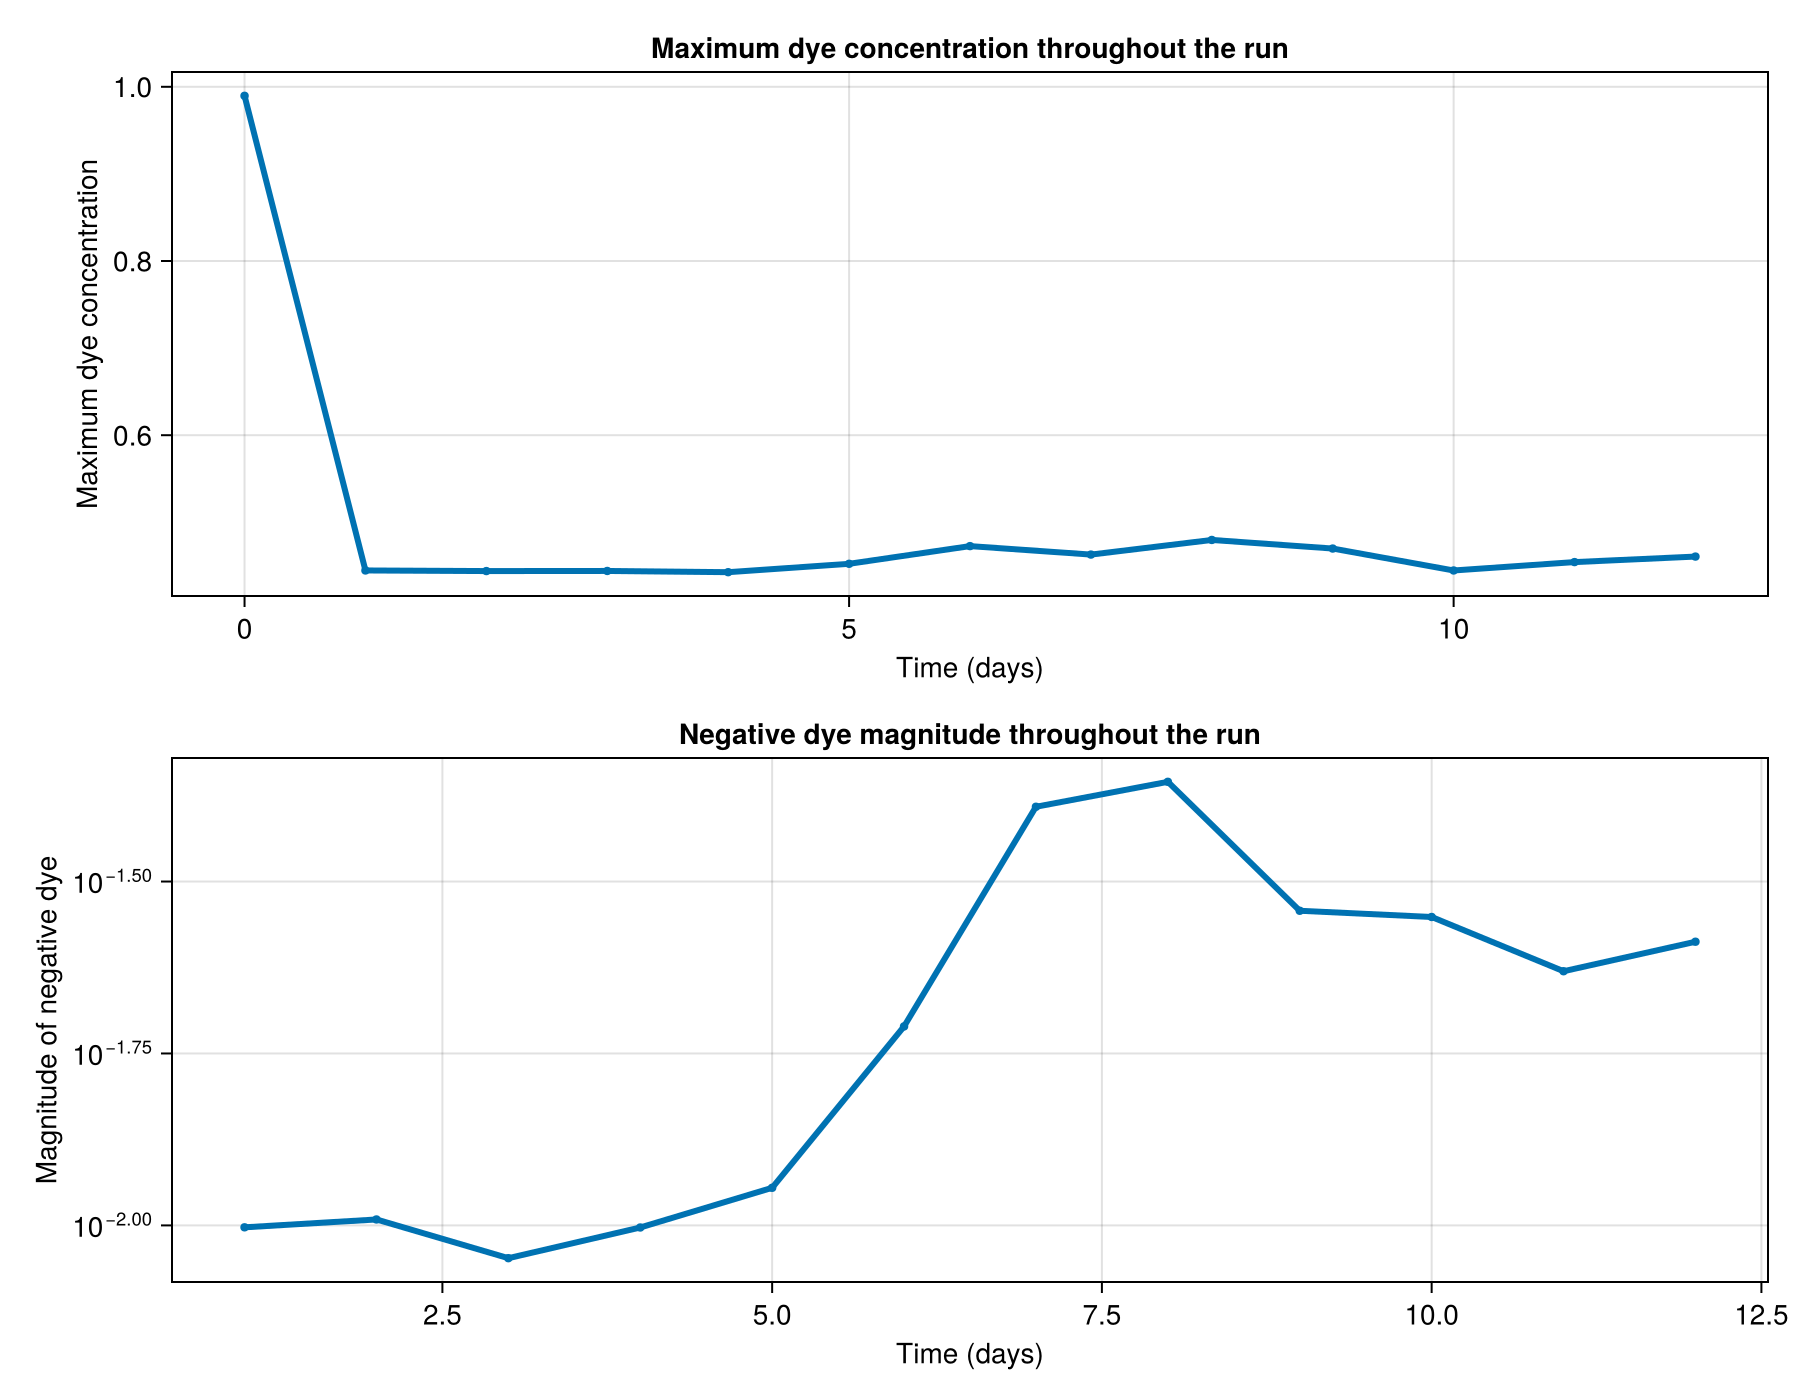

In [23]:
using Oceananigans
using CairoMakie

# load the saved 3d dye output
dye_series = FieldTimeSeries(dye_3d_filename, "dye")

Nt = length(dye_series.times)

time_days = dye_series.times ./ days
minimum_dye = zeros(Float64, Nt)
maximum_dye = zeros(Float64, Nt)

for n in 1:Nt
    dye_snapshot = Array(interior(dye_series[n]))

    minimum_dye[n] = minimum(dye_snapshot)
    maximum_dye[n] = maximum(dye_snapshot)
end

# magnitude of the negative dye values
negative_dye_amount = max.(-minimum_dye, 0)

fig = Figure(size = (900, 700))

ax1 = Axis(
    fig[1, 1],
    xlabel = "Time (days)",
    ylabel = "Maximum dye concentration",
    title = "Maximum dye concentration throughout the run"
)

lines!(
    ax1,
    time_days,
    maximum_dye;
    linewidth = 3
)

scatter!(
    ax1,
    time_days,
    maximum_dye;
    markersize = 6
)

ax2 = Axis(
    fig[2, 1],
    xlabel = "Time (days)",
    ylabel = "Magnitude of negative dye",
    title = "Negative dye magnitude throughout the run",
    yscale = log10
)

# avoid plotting exact zeros on a logarithmic axis
positive_negative_indices = findall(negative_dye_amount .> 0)

lines!(
    ax2,
    time_days[positive_negative_indices],
    negative_dye_amount[positive_negative_indices];
    linewidth = 3
)

scatter!(
    ax2,
    time_days[positive_negative_indices],
    negative_dye_amount[positive_negative_indices];
    markersize = 6
)

save("amazon_$(output_tag)_dye_extrema.png", fig)

fig